# 11_02 — Molecule aggregation (v6.2: one clean MOL_DEV experiment)

The frozen spectrum ranker (`V1_TL_1K_TESTSIM_STRICT`) is **not** touched. This notebook decides how
the ranker's per-spectrum candidate rankings are combined into **one ranking per molecule**.

* **Protocols are configuration.** `PRIMARY_PROTOCOL = test_simulated_strict` selects the aggregator. The
  visible TEST is `STRICT_LIKE` (10v6_00). `mirror_aware` is a sensitivity: it is reported and never selects.
  Both run through the same code, and only the feature table differs.
* **Features.** MOL_DEV features come from the sidecar-validated protocol artifacts
  `outputs/v5/features/protocols/MOL_DEV_<protocol>.parquet`. When the MOL_DEV QCR exists they are derived
  here, by filter + aggregate only. If the QCR is missing, the notebook stops with exact build instructions.
  The stale `features/MOL_DEV_mirror_aware.parquet` is never read.
* **Calibration.** `p = softmax(score / T)` over each spectrum's full pool. T is fitted on the frozen model's
  own training OOF (development data, never HOST, never MOL_DEV), with log T in [-3, 3]. NLL, ECE, top-1
  Brier and reliability are diagnostics only.
* **Aggregators** (absent-candidate policy verified on a fixture before use):
  * A1 max score, A2 max prob, A3 mean prob (absent = 0)
  * A4 sum log prob (absent = log eps, with eps options fixed in advance)
  * A5 log-mean-exp over present spectra, A6 RRF k = 60
  * A7 most-confident spectrum, A8 first spectrum (the spectrum baseline)
* **Metric.** Molecule MRR@25 under test-like multiplicity: 20 deterministic resamples, each drawing m spectra
  per molecule from the visible-TEST spectra-per-molecule distribution. The draws are identical for every
  aggregator and protocol. CIs come from a molecule (= connectivity) bootstrap.
* **Selection** (pre-registered, MOL_DEV only, locked before HOST). The best mean MRR wins. If another
  aggregator's paired molecule-bootstrap CI against the best contains 0, the simplest such aggregator wins.
* **HOST** is confirmation only, after the lock.
* **Export.** Candidates are deduplicated by connectivity before the Top-25 cut. The exported bundle config is
  checked to reproduce the DEV ranking exactly on the inference path. The bundle is changed only when
  `UPDATE_BUNDLE = True`.

In [1]:
import sys, json
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- configuration: protocols are configuration, not code paths ----------------------------------------
PRIMARY_PROTOCOL = 'test_simulated_strict'
SENSITIVITY_PROTOCOLS = ['mirror_aware']          # reported only; never selects
RUN_SENSITIVITY = True
AUTO_DERIVE_PROTOCOL_FEATURES = True              # filter + aggregate of the EXISTING MOL_DEV QCR; never builds QCR
N_RESAMPLES, N_BOOT = 20, 2000
A4_EPS_OPTIONS = (1e-3, 1e-6, 1e-9)               # fixed BEFORE any result
UPDATE_BUNDLE = False                             # True: write the selected aggregator into bundle/config.json

from casmi.paths import get_project_paths
from casmi.qcr.context import HOST_INGEST_LIB, SEED, v4b_paths, v5_paths
from casmi.qcr.settlement import load_settlement_or_refuse
from casmi.ranking.freeze import require_frozen_spectrum_model
from casmi.ranking.lambdamart import load_fold_models
from casmi.ranking.manifests import load_manifest
from casmi.ranking.selection import guard_no_host, require_dev_selection_lock, write_preregistration
from casmi.ranking.calibration import calibration_report, fit_temperature
from casmi.ranking import molecule_eval as me
from casmi.validation.cluster_bootstrap import cluster_bootstrap_mean
from casmi.validation.decision_log import log_decision
from casmi.validation.realism import primary_eval_protocols
from casmi_infer.aggregation import (FirstSpectrum, LogMeanExp, MaxProb, MaxScore, MeanProb, MostConfidentSpectrum, RRFAggregator,
                                     SumLogProb)

paths = get_project_paths()
vp, D = v4b_paths(paths), v5_paths(paths)
OUT = paths.outputs / 'v6' / 'aggregation'
FIG = OUT / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
KEY = 'candidate_connectivity_key'

# FIRST: the frozen-model guard (model-file sha256s, feature-order hash, protocol hash); the model is never modified
freeze = require_frozen_spectrum_model(D['freeze'] / 'spectrum_model.json')
assert freeze['protocol'] == PRIMARY_PROTOCOL, f"frozen model protocol {freeze['protocol']!r} != PRIMARY_PROTOCOL"
REALISM = freeze.get('validation_realism_status')
SELECTION_PROTOCOLS = primary_eval_protocols(REALISM)
assert SELECTION_PROTOCOLS[0] == PRIMARY_PROTOCOL, f'validation realism {REALISM!r} no longer supports {PRIMARY_PROTOCOL} as primary; re-read 10v6_00'
closure_path = paths.outputs / 'v6' / 'test_match' / 'protocol_closure.json'
if closure_path.exists() and json.loads(closure_path.read_text(encoding='utf-8')).get('protocol_work_status') == 'REOPEN_REQUIRED':
    raise RuntimeError('10v6_00 identity audit reported a correctness failure (protocol_closure.json); fix it before aggregation')
PROTOCOLS = list(dict.fromkeys(SELECTION_PROTOCOLS + (SENSITIVITY_PROTOCOLS if RUN_SENSITIVITY else [])))
models, model_meta = load_fold_models(freeze['model_dir'])
FEATS = freeze['feature_names']
print('frozen spectrum model:', freeze['model_id'], '|', freeze['freeze_status'], '| realism:', REALISM,
      '| selection protocols:', SELECTION_PROTOCOLS, '| all protocols:', PROTOCOLS)

AGGS = [MaxScore(KEY), MaxProb(KEY), MeanProb(KEY), *[SumLogProb(eps=e, cand_col=KEY) for e in A4_EPS_OPTIONS], LogMeanExp(KEY),
        RRFAggregator(k=60, cand_col=KEY), MostConfidentSpectrum(KEY), FirstSpectrum(KEY)]
agg_id = lambda a: a.name if a.name != 'A4_sum_log_prob' else f'A4_sum_log_prob_eps{a.eps:g}'
SIMPLICITY = {agg_id(a): a.simplicity for a in AGGS}
POLICY_CHECK = me.verify_absent_candidate_policy(AGGS, cand_col=KEY)      # raises unless every aggregator follows the documented policy

PREREG, LOCK_PATH = OUT / 'preregistration_aggregator_v6_2.json', OUT / 'aggregator_lock_v6_2.json'
prereg = write_preregistration(PREREG, rule={
    'rule_id': 'v6.2-aggregator-1',
    'population': 'MOL_DEV (training-disjoint, TL_EVAL-disjoint, no HOST source/structure; >=3 spectra per connectivity)',
    'spectrum_model': freeze['model_id'], 'selection_protocols': SELECTION_PROTOCOLS, 'sensitivity_protocols': SENSITIVITY_PROTOCOLS,
    'metric': f'molecule MRR@{me.MRR_K} averaged over {N_RESAMPLES} test-like multiplicity resamples (visible-TEST spectra-per-molecule)',
    'selection': 'best mean; any aggregator whose paired molecule-bootstrap CI vs best contains 0 is within CI -> the simplest within CI wins',
    'multi_protocol': 'one selection protocol -> its choice; several -> common choice, else the simplest per-protocol choice',
    'aggregators': list(SIMPLICITY), 'simplicity': SIMPLICITY, 'absent_candidate_policy': me.ABSENT_CANDIDATE_POLICY,
    'temperature': 'frozen model training OOF only; log T in [-3, 3]; calibration metrics diagnostic',
    'bootstrap': f'molecule (= connectivity) clusters, {N_BOOT} replicates, seed {SEED}',
    'paired_comparisons': [f'selected - {b}' for b in me.PAIRED_BASELINES + (me.SPECTRUM_BASELINE,)],
    'host_role': 'confirmation only, after the lock', 'tie_rule': ['aggregate score DESC', 'secondary ASC', 'connectivity_key ASC'],
    'final_rank': 'candidate union over the molecule spectra, deduplicated by connectivity BEFORE the top-25 cut'})
print('aggregator rule sha256:', prereg['rule_sha256'])

frozen spectrum model: V1_TL_1K_TESTSIM_STRICT | FROZEN | realism: STRICT_LIKE | selection protocols: ['test_simulated_strict'] | all protocols: ['test_simulated_strict', 'mirror_aware']
aggregator rule sha256: 89aa41b0d4c19ef198024f2604c01c4da24e9eb7c81bd2dd969a861f3910df3e


## 1. Temperature from development data only (the frozen model's own training OOF)

The OOF rows must belong to the frozen model's training manifest, and they must be disjoint from MOL_DEV.
HOST-named columns are refused. One T is used for every protocol. For `mirror_aware` this is part of the
sensitivity: the model and T are both strict.

In [2]:
train_man, _ = load_manifest(freeze['manifest'], D['manifests'])
mol_man, mol_meta = load_manifest('MOL_DEV', D['manifests'])
tl_eval_man, _ = load_manifest('TL_EVAL', D['manifests'])
oof = pd.read_parquet(Path(freeze['model_dir']) / 'oof_rows.parquet')
guard_no_host(oof, 'temperature fit input')
oof_ids = set(oof['query_id'].astype(str))
assert oof_ids <= set(train_man['query_id'].astype(str)), 'OOF rows are not the frozen model training OOF'
assert not (oof_ids & set(mol_man['query_id'].astype(str))), 'OOF overlaps MOL_DEV'
TEMP = fit_temperature(oof, score_col='score', group_col='query_id', truth_col='is_true_candidate')
T = TEMP['temperature']
cal_oof, rel_oof = calibration_report(oof, T)
print(json.dumps(TEMP, indent=1))
print('calibration on training OOF (diagnostic):', cal_oof)

{
 "temperature": 1.1947045372735254,
 "log_temperature": 0.17789890566887195,
 "nll": 0.2142414641444589,
 "nll_at_T1": 0.2203716250965503,
 "n_spectra": 1000,
 "at_bound": false
}
calibration on training OOF (diagnostic): {'temperature': 1.1947045372735254, 'nll': 0.2142414641444589, 'brier': 0.07952948726290991, 'brier_top1': 0.03150804862330451, 'ece_top1': 0.01893622439651525, 'n_spectra': 1000}


## 2. MOL_DEV artifacts: readiness, with no silent substitution

There are three possible outcomes:

* The QCR exists and a valid sidecar is present: the features are reused.
* The QCR exists but the protocol artifact is missing or stale: it is derived here by filter + aggregate.
* The QCR is missing: the notebook stops with the exact build commands. A missing sensitivity protocol only
  drops that protocol.

In [3]:
from casmi.qcr.protocol_features import READY, artifact_status, build_protocol_artifacts, feature_path, qcr_status

settlement = load_settlement_or_refuse(vp.settlement_json)
EVID = settlement['evidence_fingerprint']
QCR_READY = qcr_status(D, 'MOL_DEV') == READY
STATUS = {p: artifact_status(D, 'MOL_DEV', p, EVID) for p in PROTOCOLS}
if AUTO_DERIVE_PROTOCOL_FEATURES and QCR_READY:
    for p in PROTOCOLS:
        if STATUS[p] != READY:
            print(build_protocol_artifacts(D, 'MOL_DEV', p, EVID, derive_training_manifest=False))
            STATUS[p] = artifact_status(D, 'MOL_DEV', p, EVID)
READINESS = pd.DataFrame([{'protocol': p, 'role': 'selection' if p in SELECTION_PROTOCOLS else 'sensitivity', 'mol_dev_qcr': 'READY' if QCR_READY else 'MISSING',
                           'feature_artifact': STATUS[p], 'path': str(feature_path(D, 'MOL_DEV', p))} for p in PROTOCOLS])
display(READINESS)
legacy = D['features'] / 'MOL_DEV_mirror_aware.parquet'
print(f'legacy {legacy.name}:', 'present (NOT read)' if legacy.exists() else 'absent (not needed)')
missing = [p for p in PROTOCOLS if STATUS[p] != READY]
if any(p in SELECTION_PROTOCOLS for p in missing):
    raise me.MolDevNotReady(me.moldev_build_instructions(QCR_READY, missing))
if missing:
    print('sensitivity protocol(s) skipped:', missing, '\n' + me.moldev_build_instructions(QCR_READY, missing))
    PROTOCOLS = [p for p in PROTOCOLS if p not in missing]

{'name': 'MOL_DEV', 'protocol': 'mirror_aware', 'reused': False, 'n_feature_rows': 660860, 'n_queries': 1822}


,protocol,role,mol_dev_qcr,feature_artifact,path
0,test_simulated_strict,selection,READY,READY,C:\Users\myben\OneDrive\Documents\Enveda\outpu...
1,mirror_aware,sensitivity,READY,READY,C:\Users\myben\OneDrive\Documents\Enveda\outpu...


legacy MOL_DEV_mirror_aware.parquet: present (NOT read)


## 3. MOL_DEV spectrum predictions (frozen, out-of-sample) + calibration diagnostics

Spectra are ranked with the inference tie rule (score DESC, abs ppm ASC, connectivity ASC). Probabilities
are computed over each spectrum's full pool. The development molecule is its truth connectivity, and
resampling draws from the manifest, so a spectrum with an empty pool still consumes a draw.

MOL_DEV requirements: {'disjoint_from_training': True, 'disjoint_from_excluded': True, 'no_host_structures': True, 'no_host_source': True, 'multi_spectrum_molecules': True, 'n_molecules': 400, 'n_spectra': 1822}


,population,protocol,temperature,nll,brier,brier_top1,ece_top1,n_spectra,spectrum_level_mrr_at_25,n_spectra_with_candidates,n_spectra_manifest
0,training_OOF,test_simulated_strict,1.194705,0.214241,0.079529,0.031508,0.018936,1000,NaN,NaN,NaN
1,MOL_DEV,test_simulated_strict,1.194705,0.165617,0.054049,0.022691,0.012653,1822,0.975926,1822.0,1822.0
2,MOL_DEV,mirror_aware,1.194705,4.705232,0.993346,0.050997,0.041404,1822,0.100622,1822.0,1822.0


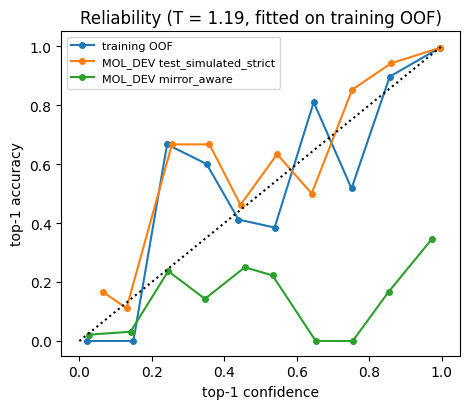

In [4]:
ALL_SPECTRA = (mol_man.rename(columns={'query_id': 'spectrum_id', 'connectivity_key': 'molecule_id'})[['molecule_id', 'spectrum_id']]
               .astype(str).sort_values(['molecule_id', 'spectrum_id']).reset_index(drop=True))
TRUTH = {m: m for m in sorted(ALL_SPECTRA['molecule_id'].unique())}      # a development molecule IS its connectivity
REQ = me.mol_dev_requirements(mol_man, ALL_SPECTRA, train_man['connectivity_key'], tl_eval_man['connectivity_key'],
                              me.host_connectivity_keys(vp.host_processed), HOST_INGEST_LIB)
print('MOL_DEV requirements:', REQ)

PER_SPEC, CAL_ROWS, REL = {}, [{'population': 'training_OOF', 'protocol': freeze['protocol'], **cal_oof}], {'training OOF': rel_oof}
for p in PROTOCOLS:
    f = pd.read_parquet(feature_path(D, 'MOL_DEV', p))
    assert set(f['query_id'].astype(str)) <= set(ALL_SPECTRA['spectrum_id']), f'{p}: feature rows outside the MOL_DEV manifest'
    PER_SPEC[p] = me.score_spectra(models, f, FEATS, T, KEY)
    assert set(PER_SPEC[p]['molecule_id']) <= set(TRUTH)
    cal, rel = calibration_report(PER_SPEC[p], T, group_col='spectrum_id')
    CAL_ROWS.append({'population': 'MOL_DEV', 'protocol': p, **cal,
                     'spectrum_level_mrr_at_25': me.spectrum_level_mrr(PER_SPEC[p], ALL_SPECTRA),
                     'n_spectra_with_candidates': int(PER_SPEC[p]['spectrum_id'].nunique()), 'n_spectra_manifest': int(len(ALL_SPECTRA))})
    REL[f'MOL_DEV {p}'] = rel
CAL = pd.DataFrame(CAL_ROWS)
CAL.to_csv(OUT / 'calibration_metrics.csv', index=False)
(OUT / 'calibration.json').write_text(json.dumps({'temperature_fit': TEMP, 'fit_population': 'frozen model training OOF (oof_rows.parquet)',
                                                  'host_used': False, 'metrics': CAL.to_dict('records'),
                                                  'reliability_bins': {k: v.to_dict('records') for k, v in REL.items()}}, indent=2, default=str), encoding='utf-8')
display(CAL)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
for lab, rel in REL.items():
    r = rel[rel['n'] > 0]
    ax.plot(r['mean_confidence'], r['accuracy'], 'o-', ms=4, label=lab)
ax.plot([0, 1], [0, 1], 'k:'); ax.set_xlabel('top-1 confidence'); ax.set_ylabel('top-1 accuracy'); ax.legend(fontsize=8)
ax.set_title(f'Reliability (T = {T:.3g}, fitted on training OOF)'); fig.tight_layout(); fig.savefig(FIG / 'reliability.png', dpi=130); plt.show()

## 4. Aggregators under test-like multiplicity (MOL_DEV only) → `aggregator_metrics.csv`

visible-TEST spectra per molecule: {1: 55, 2: 97, 3: 99, 4: 106, 5: 24, 6: 14, 7: 2, 8: 2, 9: 1}


,aggregator,dev_mrr_mean,dev_mrr_sd_over_resamples,ci_low,ci_high,delta_vs_best,delta_ci_low,delta_ci_high,n_molecules,protocol,role
0,A4_sum_log_prob_eps0.001,0.9961,0.0020,0.9944,0.9976,0.0000,0.0000,0.0000,400,test_simulated_strict,selection
1,A3_mean_prob,0.9961,0.0020,0.9943,0.9976,-0.0001,-0.0003,0.0001,400,test_simulated_strict,selection
2,A5_logmeanexp_present,0.9961,0.0020,0.9943,0.9976,-0.0001,-0.0003,0.0001,400,test_simulated_strict,selection
3,A4_sum_log_prob_eps1e-06,0.9960,0.0022,0.9943,0.9975,-0.0002,-0.0004,0.0000,400,test_simulated_strict,selection
4,A4_sum_log_prob_eps1e-09,0.9960,0.0022,0.9943,0.9975,-0.0002,-0.0004,0.0000,400,test_simulated_strict,selection
5,A2_max_prob,0.9954,0.0016,0.9927,0.9975,-0.0007,-0.0021,0.0000,400,test_simulated_strict,selection
6,A7_most_confident_spectrum,0.9952,0.0016,0.9921,0.9975,-0.0010,-0.0029,0.0000,400,test_simulated_strict,selection
7,A1_max_score,0.9945,0.0021,0.9918,0.9967,-0.0017,-0.0037,-0.0001,400,test_simulated_strict,selection
8,A6_rrf,0.9837,0.0036,0.9765,0.9901,-0.0125,-0.0190,-0.0069,400,test_simulated_strict,selection
9,A8_first_spectrum,0.9796,0.0034,0.9698,0.9884,-0.0165,-0.0260,-0.0081,400,test_simulated_strict,selection


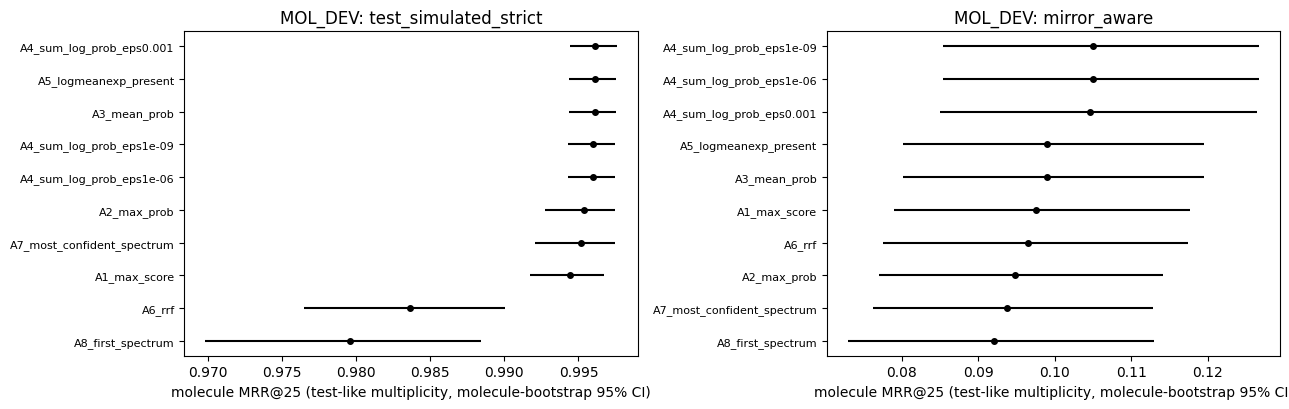

In [5]:
test_mult = pd.read_parquet(paths.processed / 'test_molecule_map.parquet')['n_spectra'].to_numpy()
print('visible-TEST spectra per molecule:', pd.Series(test_mult).value_counts().sort_index().to_dict())
RR, METRICS, PER_MOL = {}, {}, {}
for p in PROTOCOLS:
    RR[p] = me.evaluate_aggregators(PER_SPEC[p], TRUTH, AGGS, agg_id, test_mult, ALL_SPECTRA, n_resamples=N_RESAMPLES, seed=SEED, cand_col=KEY)
    METRICS[p], PER_MOL[p] = me.aggregator_metrics(RR[p], n_boot=N_BOOT, seed=SEED)
pd.concat([RR[p].assign(protocol=p) for p in PROTOCOLS], ignore_index=True).to_parquet(OUT / 'moldev_rr_long.parquet', index=False)
AGG_METRICS = pd.concat([METRICS[p].assign(protocol=p, role='selection' if p in SELECTION_PROTOCOLS else 'sensitivity') for p in PROTOCOLS],
                        ignore_index=True)
AGG_METRICS.to_csv(OUT / 'aggregator_metrics.csv', index=False)
display(AGG_METRICS.round(4))

fig, axes = plt.subplots(1, len(PROTOCOLS), figsize=(6.5 * len(PROTOCOLS), 4.2), squeeze=False)
for ax, p in zip(axes[0], PROTOCOLS):
    m = METRICS[p].sort_values('dev_mrr_mean')
    ax.errorbar(m['dev_mrr_mean'], np.arange(len(m)), xerr=[m['dev_mrr_mean'] - m['ci_low'], m['ci_high'] - m['dev_mrr_mean']], fmt='o', color='k', ms=4)
    ax.set_yticks(np.arange(len(m))); ax.set_yticklabels(m['aggregator'], fontsize=8)
    ax.set_xlabel(f'molecule MRR@{me.MRR_K} (test-like multiplicity, molecule-bootstrap 95% CI)'); ax.set_title(f'MOL_DEV: {p}')
fig.tight_layout(); fig.savefig(FIG / 'aggregator_mrr.png', dpi=130); plt.show()

## 5. Pre-registered DEV selection → LOCK (before any HOST access)

In [6]:
from casmi.ranking.selection import lock_dev_selection

SEL_BY_PROTOCOL, RANKED = {}, {}
for p in SELECTION_PROTOCOLS:
    SEL_BY_PROTOCOL[p], _best, RANKED[p] = me.select_aggregator_dev_only(
        METRICS[p][['aggregator', 'dev_mrr_mean', 'delta_ci_low', 'delta_ci_high']], SIMPLICITY)
SELECTED, SELECTION_REASON = me.select_across_protocols(SEL_BY_PROTOCOL, SIMPLICITY)
sel_obj = next(a for a in AGGS if agg_id(a) == SELECTED)
AGG_CFG = me.aggregator_export_config(sel_obj, SELECTED, T)
lock_dev_selection(LOCK_PATH, SELECTED, RANKED[PRIMARY_PROTOCOL], {'temperature': T}, PREREG,
                   extra={'aggregator_config': AGG_CFG, 'selection_by_protocol': SEL_BY_PROTOCOL, 'selection_reason': SELECTION_REASON,
                          'best_raw_by_protocol': {p: RANKED[p].sort_values('dev_mrr_mean', ascending=False).iloc[0]['aggregator'] for p in RANKED}})
log_decision(decision=f'v6.2 molecule aggregator (MOL_DEV {SELECTION_PROTOCOLS}): {SELECTED}',
             evidence_used='outputs/v6/aggregation/aggregator_metrics.csv; no HOST metric', host_visible=False,
             category='pre_registered_choice', log_path=paths.outputs / 'decision_log.jsonl')
display(RANKED[PRIMARY_PROTOCOL])
print('SELECTED aggregator:', SELECTED, '|', SELECTION_REASON, '|', AGG_CFG)

,aggregator,dev_mrr_mean,delta_ci_low,delta_ci_high,within_ci_of_best,simplicity,selection_order
0,A7_most_confident_spectrum,0.995176,-0.002887,0.000000,True,1,1
1,A2_max_prob,0.995395,-0.002100,0.000000,True,3,2
2,A3_mean_prob,0.996082,-0.000281,0.000113,True,4,3
3,A5_logmeanexp_present,0.996082,-0.000281,0.000113,True,5,4
4,A4_sum_log_prob_eps0.001,0.996139,0.000000,0.000000,True,6,5
5,A4_sum_log_prob_eps1e-06,0.995968,-0.000425,0.000000,True,6,6
6,A4_sum_log_prob_eps1e-09,0.995968,-0.000425,0.000000,True,6,7
7,A8_first_spectrum,0.979622,-0.025955,-0.008149,False,0,8
8,A1_max_score,0.994457,-0.003706,-0.000112,False,1,9
9,A6_rrf,0.983671,-0.018996,-0.006853,False,2,10


SELECTED aggregator: A7_most_confident_spectrum | all evaluation protocols agree | {'name': 'A7_most_confident_spectrum', 'aggregator_id': 'A7_most_confident_spectrum', 'temperature': 1.1947045372735254, 'tie_rule': ['aggregate score DESC', 'mean abs ppm over present spectra ASC', 'connectivity_key ASC']}


## 6. DEV-only reporting for the locked choice

This section covers:

* paired molecule-bootstrap deltas (selected − RRF, − A1 max score, − A7 most-confident, − A8 first spectrum);
* the gain by label-free matchability tier (the MOL_DEV analogue of the TEST proxy, used for reporting only);
* the final Top-25 per molecule (connectivity-deduplicated, with representative SMILES);
* an exact check that the exported config reproduces the DEV ranking on the inference path.

In [7]:
BOOT = pd.concat([me.paired_deltas(PER_MOL[p], SELECTED, me.PAIRED_BASELINES + (me.SPECTRUM_BASELINE,), n_boot=N_BOOT, seed=SEED)
                  .assign(protocol=p) for p in PROTOCOLS], ignore_index=True)
BOOT.to_csv(OUT / 'aggregator_bootstrap.csv', index=False)
display(BOOT.round(4))

STRAT = []
for p in PROTOCOLS:
    tiers = me.molecule_matchability(PER_SPEC[p], ALL_SPECTRA)
    STRAT.append(me.improvement_by_matchability(PER_MOL[p], tiers, SELECTED, n_boot=N_BOOT, seed=SEED).assign(protocol=p))
STRAT = pd.concat(STRAT, ignore_index=True)
STRAT.to_csv(OUT / 'aggregation_by_matchability.csv', index=False)
display(STRAT.round(4))

conn_table = pd.read_parquet(D['bundle'] / 'connectivities.parquet', columns=['connectivity_key', 'representative_smiles'])
FINAL = me.with_representative_smiles(me.molecule_top_k(sel_obj.rank(PER_SPEC[PRIMARY_PROTOCOL])), conn_table, KEY)
FINAL = FINAL.assign(protocol=PRIMARY_PROTOCOL, aggregator=SELECTED, is_truth_candidate=FINAL[KEY] == FINAL['molecule_id'])
assert not FINAL.duplicated(['molecule_id', KEY]).any() and (FINAL.groupby('molecule_id').size() <= me.MRR_K).all()
FINAL.to_parquet(OUT / 'moldev_predictions.parquet', index=False)
N_ROUNDTRIP = me.verify_aggregator_roundtrip(sel_obj, AGG_CFG, PER_SPEC[PRIMARY_PROTOCOL], KEY)
print(f'exported config reproduces the DEV ranking exactly ({N_ROUNDTRIP:,} molecule-candidate rows)')

sel_row = lambda p, a: METRICS[p].set_index('aggregator').loc[a]
SELECTED_RECORD = {
    'selected_aggregator': SELECTED, 'aggregator_config': AGG_CFG, 'selection_reason': SELECTION_REASON, 'selection_by_protocol': SEL_BY_PROTOCOL,
    'selection_protocols': SELECTION_PROTOCOLS, 'sensitivity_protocols': [p for p in PROTOCOLS if p not in SELECTION_PROTOCOLS],
    'validation_realism_status': REALISM, 'spectrum_model': freeze['model_id'], 'spectrum_model_unchanged': True,
    'temperature': T, 'preregistration_sha256': prereg['rule_sha256'], 'lock': str(LOCK_PATH),
    'dev_metrics': {p: {a: {k: float(sel_row(p, a)[k]) for k in ('dev_mrr_mean', 'dev_mrr_sd_over_resamples', 'ci_low', 'ci_high')}
                        for a in (SELECTED, 'A6_rrf', me.SPECTRUM_BASELINE)} for p in PROTOCOLS},
    'paired_deltas': BOOT.to_dict('records'), 'roundtrip_rows_verified': N_ROUNDTRIP, 'host_role': 'confirmation only (host_confirmation.csv)'}
(OUT / 'selected_aggregator.json').write_text(json.dumps(SELECTED_RECORD, indent=2, default=str), encoding='utf-8')
(OUT / 'aggregator_bundle_config.json').write_text(json.dumps(AGG_CFG, indent=2), encoding='utf-8')

,comparison,selected,other,delta,ci_low,ci_high,n_molecules,protocol
0,A7_most_confident_spectrum - A6_rrf,A7_most_confident_spectrum,A6_rrf,0.0115,0.0056,0.0184,400,test_simulated_strict
1,A7_most_confident_spectrum - A1_max_score,A7_most_confident_spectrum,A1_max_score,0.0007,-0.0023,0.0031,400,test_simulated_strict
2,A7_most_confident_spectrum - A7_most_confident...,A7_most_confident_spectrum,A7_most_confident_spectrum,0.0000,0.0000,0.0000,400,test_simulated_strict
3,A7_most_confident_spectrum - A8_first_spectrum,A7_most_confident_spectrum,A8_first_spectrum,0.0156,0.0068,0.0252,400,test_simulated_strict
4,A7_most_confident_spectrum - A6_rrf,A7_most_confident_spectrum,A6_rrf,-0.0027,-0.0107,0.0052,400,mirror_aware
5,A7_most_confident_spectrum - A1_max_score,A7_most_confident_spectrum,A1_max_score,-0.0038,-0.0088,0.0003,400,mirror_aware
6,A7_most_confident_spectrum - A7_most_confident...,A7_most_confident_spectrum,A7_most_confident_spectrum,0.0000,0.0000,0.0000,400,mirror_aware
7,A7_most_confident_spectrum - A8_first_spectrum,A7_most_confident_spectrum,A8_first_spectrum,0.0017,-0.0058,0.0087,400,mirror_aware


,matchability_tier,n_molecules,selected,baseline,mrr_selected,mrr_baseline,delta,ci_low,ci_high,protocol
0,HIGH,389,A7_most_confident_spectrum,A8_first_spectrum,0.9951,0.9792,0.0160,0.0067,0.0265,test_simulated_strict
1,HIGH,389,A7_most_confident_spectrum,A6_rrf,0.9951,0.9835,0.0116,0.0055,0.0187,test_simulated_strict
2,MEDIUM,11,A7_most_confident_spectrum,A8_first_spectrum,0.9961,0.9961,0.0000,0.0000,0.0000,test_simulated_strict
3,MEDIUM,11,A7_most_confident_spectrum,A6_rrf,0.9961,0.9885,0.0076,0.0000,0.0227,test_simulated_strict
4,HIGH,169,A7_most_confident_spectrum,A8_first_spectrum,0.0738,0.0731,0.0007,-0.0077,0.0078,mirror_aware
5,HIGH,169,A7_most_confident_spectrum,A6_rrf,0.0738,0.0820,-0.0082,-0.0169,-0.0009,mirror_aware
6,LOW,63,A7_most_confident_spectrum,A8_first_spectrum,0.1751,0.1983,-0.0232,-0.0516,-0.0013,mirror_aware
7,LOW,63,A7_most_confident_spectrum,A6_rrf,0.1751,0.1853,-0.0102,-0.0417,0.0247,mirror_aware
8,MEDIUM,168,A7_most_confident_spectrum,A8_first_spectrum,0.0833,0.0712,0.0121,0.0017,0.0257,mirror_aware
9,MEDIUM,168,A7_most_confident_spectrum,A6_rrf,0.0833,0.0777,0.0056,-0.0045,0.0190,mirror_aware


exported config reproduces the DEV ranking exactly (146,562 molecule-candidate rows)


249

## 7. HOST confirmation, after the lock (molecule = connectivity; descriptive only)

Nothing below can change the selection. The lock is verified against the pre-registration, and the
selected aggregator is re-checked against it at the end.

In [8]:
from casmi.qcr.protocol_features import build_host_protocol_artifacts

LOCK = require_dev_selection_lock(LOCK_PATH, PREREG)
assert LOCK.selected_model_id == SELECTED
host_q = pd.read_parquet(vp.host_processed / 'host_holdout_spectra.parquet')
HOST_ALL = host_q.rename(columns={'query_id': 'spectrum_id', 'true_connectivity_key': 'molecule_id'})[['molecule_id', 'spectrum_id']].astype(str)
host_truth = {m: m for m in sorted(HOST_ALL['molecule_id'].unique())}
CONFIRM = list({agg_id(a): a for a in [sel_obj, RRFAggregator(k=60, cand_col=KEY), MaxScore(KEY), FirstSpectrum(KEY)]}.values())
host_rows = []
for p in PROTOCOLS:
    print(build_host_protocol_artifacts(D, settlement['evidence_artifacts'], host_q, p, EVID))
    host_spec = me.score_spectra(models, pd.read_parquet(feature_path(D, 'HOST', p)), FEATS, T, KEY)
    for a in CONFIRM:
        rr_all = me.molecule_rr(a.rank(host_spec), host_truth, KEY)
        ci = cluster_bootstrap_mean(rr_all.to_numpy(), rr_all.index.to_numpy(), n_boot=N_BOOT, seed=SEED)
        rs = [me.molecule_rr(a.rank(sub), host_truth, KEY).mean()
              for _, sub in me.multiplicity_resamples(host_spec, test_mult, N_RESAMPLES, SEED, all_spectra=HOST_ALL)]
        host_rows.append({'protocol': p, 'aggregator': agg_id(a), 'is_selected': agg_id(a) == SELECTED, 'host_mrr_all_spectra': ci['mean'],
                          'ci_low': ci['ci_low'], 'ci_high': ci['ci_high'], 'host_mrr_testlike_mean': float(np.mean(rs)),
                          'host_mrr_testlike_sd': float(np.std(rs, ddof=1)), 'n_molecules': int(len(rr_all)),
                          'n_multi_spectrum_molecules': int((HOST_ALL.groupby('molecule_id').size() >= 2).sum())})
HOST_TAB = pd.DataFrame(host_rows)
HOST_TAB.to_csv(OUT / 'host_confirmation.csv', index=False)
display(HOST_TAB.round(4))
assert json.loads(LOCK_PATH.read_text(encoding='utf-8'))['selected_model_id'] == SELECTED, 'selection changed after HOST'

{'name': 'HOST', 'reused': True}
{'name': 'HOST', 'reused': False}


,protocol,aggregator,is_selected,host_mrr_all_spectra,ci_low,ci_high,host_mrr_testlike_mean,host_mrr_testlike_sd,n_molecules,n_multi_spectrum_molecules
0,test_simulated_strict,A7_most_confident_spectrum,True,0.8904,0.8566,0.9213,0.8639,0.0090,250,220
1,test_simulated_strict,A6_rrf,False,0.8356,0.7978,0.8705,0.8159,0.0112,250,220
2,test_simulated_strict,A1_max_score,False,0.8863,0.8532,0.9174,0.8622,0.0085,250,220
3,test_simulated_strict,A8_first_spectrum,False,0.8185,0.7784,0.8559,0.8214,0.0104,250,220
4,mirror_aware,A7_most_confident_spectrum,True,0.8079,0.7682,0.8473,0.7933,0.0090,250,220
5,mirror_aware,A6_rrf,False,0.7688,0.7279,0.8087,0.7546,0.0101,250,220
6,mirror_aware,A1_max_score,False,0.7996,0.7599,0.8368,0.7865,0.0079,250,220
7,mirror_aware,A8_first_spectrum,False,0.7768,0.7346,0.8167,0.7698,0.0085,250,220


## 8. Kaggle preparation: the bundle swap is a config change

The anchor submission stays on RRF, the bundle's current aggregator. Setting `UPDATE_BUNDLE = True` writes the
selected aggregator, with its temperature, into `bundle/config.json`. This produces a new `CONFIG_HASH` and
refreshes the manifest. Then re-run `11_01` parity and re-upload the bundle. `aggregator_bundle_config.json` is
always written, so the swap can also be applied later.

In [9]:
bundle_cfg = json.loads((D['bundle'] / 'config.json').read_text(encoding='utf-8'))
print('bundle aggregator now:', bundle_cfg['aggregator'], '| CONFIG_HASH', bundle_cfg['CONFIG_HASH'])
if UPDATE_BUNDLE:
    from casmi import bundle_export as bx
    old_cfg, new_cfg = bx.apply_aggregator_config(D['bundle'], AGG_CFG, settlement['similarity_config'])
    print('bundle updated:', old_cfg['CONFIG_HASH'], '->', new_cfg['CONFIG_HASH'], '| re-run 11_01 parity before uploading')
    # applying the MOL_DEV-locked choice; HOST has been seen by now, so host_visible is recorded honestly
    log_decision(decision=f'bundle aggregator -> {SELECTED} (applies the MOL_DEV lock)', evidence_used='selected_aggregator.json',
                 host_visible=True, category='pre_registered_choice', log_path=paths.outputs / 'decision_log.jsonl')
else:
    print('bundle NOT modified (UPDATE_BUNDLE = False); anchor submission keeps', bundle_cfg['aggregator'].get('name'))

bundle aggregator now: {'name': 'RRF', 'k': 60, 'tie_rule': ['RRF DESC', 'best individual rank ASC', 'connectivity_key ASC']} | CONFIG_HASH 128372cae78ad88b
bundle NOT modified (UPDATE_BUNDLE = False); anchor submission keeps RRF


## 9. Runtime summary (every value comes from this run)

In [10]:
def _m(p, a):
    r = METRICS[p].set_index('aggregator').loc[a]
    return f"{r['dev_mrr_mean']:.4f} (sd {r['dev_mrr_sd_over_resamples']:.4f}; CI {r['ci_low']:.4f}-{r['ci_high']:.4f})"


lines = ['MOLECULE AGGREGATION (MOL_DEV, test-like multiplicity)', '']
for p in PROTOCOLS:
    b = BOOT[(BOOT['protocol'] == p) & (BOOT['other'] == 'A6_rrf')]
    lines += [f"[{p}] ({'SELECTION' if p in SELECTION_PROTOCOLS else 'sensitivity'})",
              f'  spectrum-level MRR (context): {CAL.set_index(["population", "protocol"]).loc[("MOL_DEV", p), "spectrum_level_mrr_at_25"]:.4f}',
              f'  spectrum baseline (A8 first spectrum) molecule MRR: {_m(p, me.SPECTRUM_BASELINE)}',
              f'  RRF molecule MRR: {_m(p, "A6_rrf")}',
              f'  selected ({SELECTED}) molecule MRR: {_m(p, SELECTED)}',
              (f"  delta vs RRF: {b['delta'].iloc[0]:+.4f} (CI {b['ci_low'].iloc[0]:+.4f} to {b['ci_high'].iloc[0]:+.4f})" if len(b)
               else '  delta vs RRF: selected IS RRF'), '']
lines += [f'Selected aggregator: {SELECTED}  [{SELECTION_REASON}]', f'Temperature (training OOF): {T:.4f}', '', 'HOST confirmation (descriptive):']
for r in HOST_TAB.itertuples():
    lines.append(f'  [{r.protocol}] {r.aggregator}: all-spectra {r.host_mrr_all_spectra:.4f} (CI {r.ci_low:.4f}-{r.ci_high:.4f}); test-like {r.host_mrr_testlike_mean:.4f}')
lines += ['', 'Bundle: ' + ('UPDATED with the selected aggregator' if UPDATE_BUNDLE else 'unchanged (anchor aggregator kept)'),
          '', 'NEXT: OPEN_CANDIDATES / CLASS2_VALIDATION']
print('\n'.join(lines))

MOLECULE AGGREGATION (MOL_DEV, test-like multiplicity)

[test_simulated_strict] (SELECTION)
  spectrum-level MRR (context): 0.9759
  spectrum baseline (A8 first spectrum) molecule MRR: 0.9796 (sd 0.0034; CI 0.9698-0.9884)
  RRF molecule MRR: 0.9837 (sd 0.0036; CI 0.9765-0.9901)
  selected (A7_most_confident_spectrum) molecule MRR: 0.9952 (sd 0.0016; CI 0.9921-0.9975)
  delta vs RRF: +0.0115 (CI +0.0056 to +0.0184)

[mirror_aware] (sensitivity)
  spectrum-level MRR (context): 0.1006
  spectrum baseline (A8 first spectrum) molecule MRR: 0.0921 (sd 0.0037; CI 0.0729-0.1130)
  RRF molecule MRR: 0.0965 (sd 0.0035; CI 0.0776-0.1175)
  selected (A7_most_confident_spectrum) molecule MRR: 0.0938 (sd 0.0035; CI 0.0762-0.1129)
  delta vs RRF: -0.0027 (CI -0.0107 to +0.0052)

Selected aggregator: A7_most_confident_spectrum  [all evaluation protocols agree]
Temperature (training OOF): 1.1947

HOST confirmation (descriptive):
  [test_simulated_strict] A7_most_confident_spectrum: all-spectra 0.8904 (